<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_2_Forecasting_with_Daily_Bitcoin_Price_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# BILAL-Assignment 2: Forecasting with Daily Bitcoin Price Data
# Uploading and Loading Dataset
from google.colab import files
uploaded = files.upload()

Saving bitcoin_price.csv to bitcoin_price.csv


In [5]:
# Loading Dataset
import pandas as pd

df = pd.read_csv("bitcoin_price.csv")

# Displaying first 5 rows
df.head()

,Date,Close
0,2020-01-01,7000.00
1,2020-01-02,7015.23
2,2020-01-03,6998.12
3,2020-01-04,7020.45
4,2020-01-05,7035.12


In [6]:
# Dataset Exploration
# Basic Information
# Checking shape
print("Number of rows and columns:", df.shape)

# Checking column names
print("\nColumns:", df.columns)

# Checking data types
df.info()

Number of rows and columns: (100, 2)

Columns: Index(['Date', 'Close'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    100 non-null    object 
 1   Close   100 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.7+ KB


In [7]:
# Converting Date Column to Datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df.head()

,Close
Date,
2020-01-01,7000.00
2020-01-02,7015.23
2020-01-03,6998.12
2020-01-04,7020.45
2020-01-05,7035.12


In [8]:
# Checking Missing Values
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Close    0
dtype: int64


In [9]:
# Checking Date Range
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Start Date: 2020-01-01 00:00:00
End Date: 2020-04-09 00:00:00


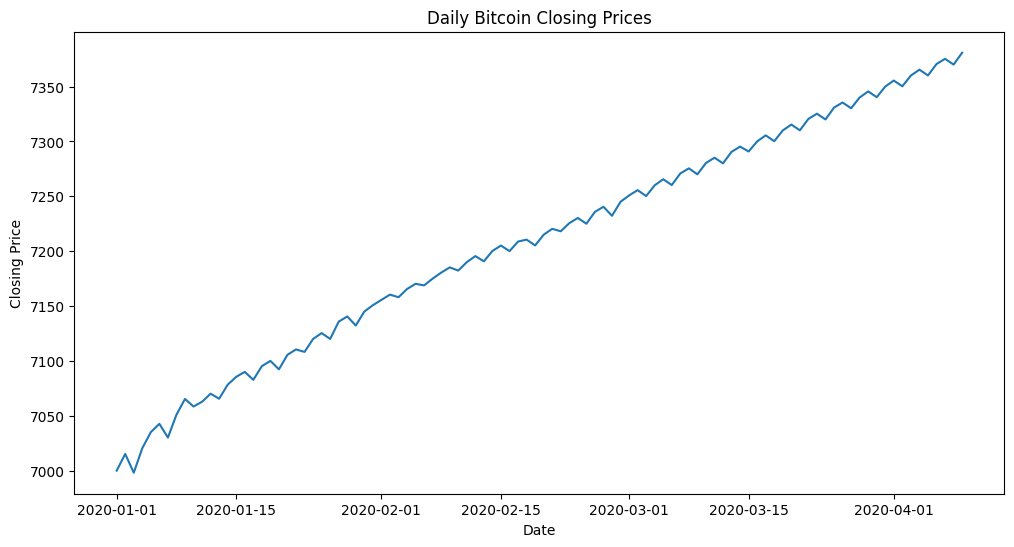

In [10]:
# Time Series Visualization
# Plotting Closing Prices
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Daily Bitcoin Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

Analysis
•	Bitcoin shows strong upward long-term growth trend.
•	High volatility with sharp rises and crashes.
•	Noticeable boom periods (e.g., 2017, 2021).
•	Large fluctuations indicate high market risk.


In [11]:
# Sliding Window Transformation
# One-Day Lag
# Creating One-Day Lag Dataset
df['Lag_1'] = df['Close'].shift(1)

# Dropping missing values
df_1lag = df.dropna()

df_1lag.head()

,Close,Lag_1
Date,,
2020-01-02,7015.23,7000.00
2020-01-03,6998.12,7015.23
2020-01-04,7020.45,6998.12
2020-01-05,7035.12,7020.45
2020-01-06,7042.67,7035.12


In [12]:
# Defining X and y
X_1 = df_1lag[['Lag_1']]
y_1 = df_1lag['Close']

In [14]:
# Two-Day Lag
# Creating Two-Day Lag Dataset
df['Lag_2'] = df['Close'].shift(2)

df_2lag = df.dropna()

df_2lag.head()

,Close,Lag_1,Lag_2
Date,,,
2020-01-03,6998.12,7015.23,7000.00
2020-01-04,7020.45,6998.12,7015.23
2020-01-05,7035.12,7020.45,6998.12
2020-01-06,7042.67,7035.12,7020.45
2020-01-07,7030.15,7042.67,7035.12


In [16]:
# Defining X and y
X_2 = df_2lag[['Lag_1', 'Lag_2']]
y_2 = df_2lag['Close']

In [17]:
# Train-Test Split (80% / 20%)
# Splitting One-Day Lag Data
from sklearn.model_selection import train_test_split

split_index = int(len(X_1) * 0.8)

X1_train = X_1[:split_index]
X1_test = X_1[split_index:]

y1_train = y_1[:split_index]
y1_test = y_1[split_index:]

In [18]:
# Two-Day Lag Data
split_index2 = int(len(X_2) * 0.8)

X2_train = X_2[:split_index2]
X2_test = X_2[split_index2:]

y2_train = y_2[:split_index2]
y2_test = y_2[split_index2:]

In [19]:
# Training Linear Regression Model
# Train One-Day Lag Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_1 = LinearRegression()
model_1.fit(X1_train, y1_train)

y1_pred = model_1.predict(X1_test)

mse_1 = mean_squared_error(y1_test, y1_pred)
print("One-Day Lag Model MSE:", mse_1)

One-Day Lag Model MSE: 45.653315299681466


In [20]:
# Training Two-Day Lag Model
model_2 = LinearRegression()
model_2.fit(X2_train, y2_train)

y2_pred = model_2.predict(X2_test)

mse_2 = mean_squared_error(y2_test, y2_pred)
print("Two-Day Lag Model MSE:", mse_2)

Two-Day Lag Model MSE: 32.904422976881264


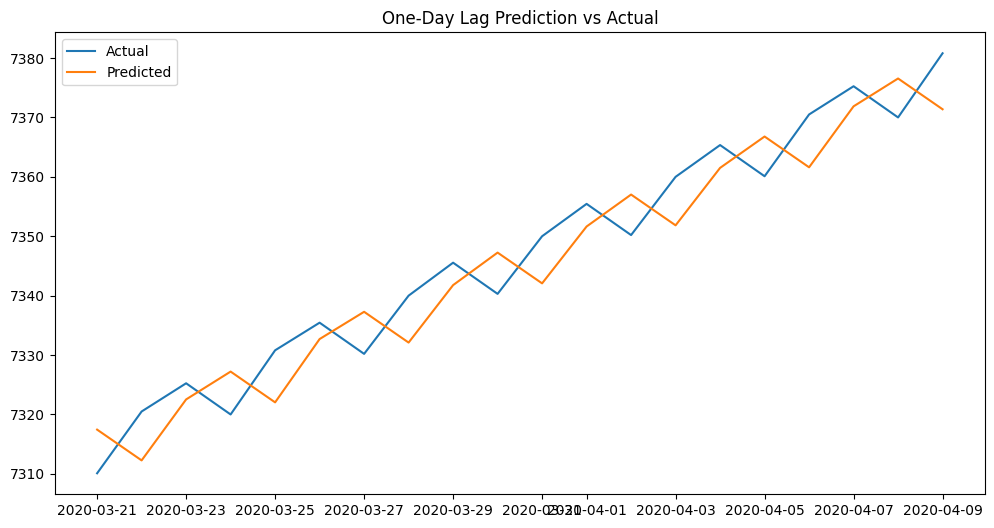

In [22]:
# Prediction Visualization
# Plotting One-Day Lag Predictions
plt.figure(figsize=(12,6))
plt.plot(y1_test.index, y1_test, label="Actual")
plt.plot(y1_test.index, y1_pred, label="Predicted")
plt.title("One-Day Lag Prediction vs Actual")
plt.legend()
plt.show()

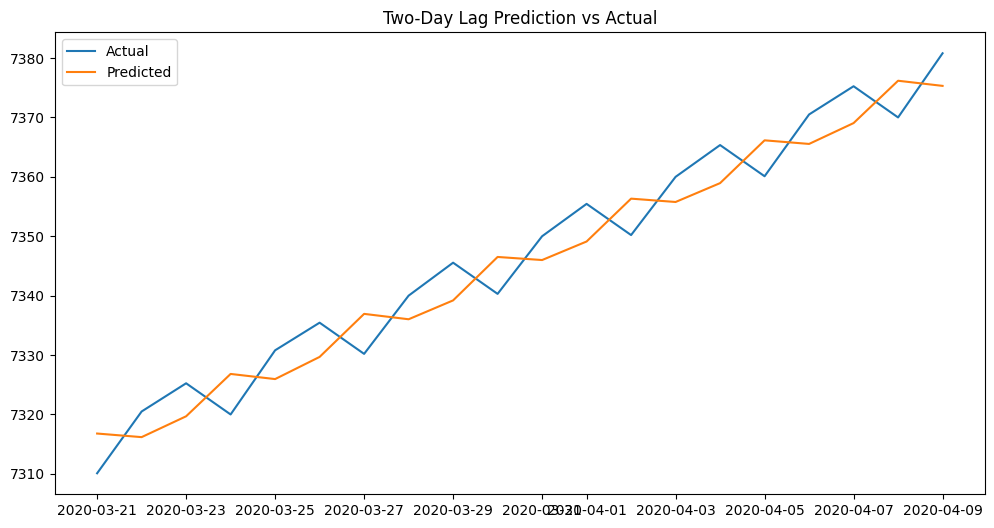

In [23]:
# Plotting Two-Day Lag Predictions
plt.figure(figsize=(12,6))
plt.plot(y2_test.index, y2_test, label="Actual")
plt.plot(y2_test.index, y2_pred, label="Predicted")
plt.title("Two-Day Lag Prediction vs Actual")
plt.legend()
plt.show()